In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

In [ ]:
# data 
X = np.array([1,3,5,8,11,14,17,20]).reshape(-1,1)
y = np.array([10,15,22,35,50,65,72,75])

In [18]:
def poly_polynomial(degree,color,label):
    # create a feature 
    poly = PolynomialFeatures(degree=degree,include_bias=False)
    X_poly = poly.fit_transform(X)

    # train model 
    model = LinearRegression()
    model.fit(X_poly,y)
    # predict smooth curce for plotting
    x_smooth = np.linspace(0,25,200).reshape(-1,1)
    x_smooth_poly = poly.transform(x_smooth)
    y_smooth = model.predict(x_smooth_poly)

    plt.plot(x_smooth , y_smooth ,color=color,linewidth=3,label=label)
    # print equation 
    coeffs = model.coef_
    intercept = model.intercept_
    print(f"\n{label} Equation")
    eq = f"y= {intercept:.2f}"
    for i , c in enumerate(coeffs):
        eq += f" + {c:.3f}*X^{i-1}"
    print(eq)
    return model,poly


Linear (degree 1) Equation
y= 2.83 + 3.688*X^-1

Quadratic (degree 2) Equation
y= 7.86 + 2.126*X^-1 + 0.075*X^0

Cubic (degree 3) Equation
y= 13.34 + -1.073*X^-1 + 0.458*X^0 + -0.012*X^1


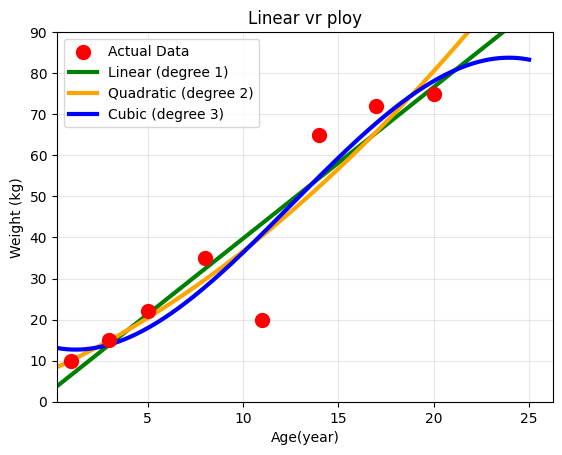

Predicted weight  at age 25 =  83.3kg


In [20]:
# create a plot three
#plt.figure(figsize=(10,6))
plt.scatter(X,y,color="red",s=100,label='Actual Data',zorder=5)
# linear (degree 1)
poly_polynomial(1,'green','Linear (degree 1)')
# Quadratic (degree 2)
poly_polynomial(2,'orange','Quadratic (degree 2)')
# Cubic (degree 3)
model_cubic , poly_cubic  = poly_polynomial(3,'blue','Cubic (degree 3)')

plt.xlabel('Age(year)')
plt.ylabel('Weight (kg)')
plt.title("Linear vr ploy")
plt.legend()
plt.grid(True,alpha=0.3)
plt.ylim(0,90)
plt.xlim(0.25)
plt.show()

# predicted 
age_25 = poly_cubic.transform([[25]])
weight_25 = model_cubic.predict(age_25)
print(f"Predicted weight  at age 25 =  {weight_25[0]:.1f}kg")